# From a demand path to inventory updates

Generate a small daily demand path, then follow an `(R, S)` policy as physical stock falls, replenishment orders are placed, and deliveries arrive after lead time.

## 1. Generate a daily demand path

`DemandGenerator` creates a complete demand calendar in the format used by the inventory APIs: one row per SKU and period, with `date` and `y`. The fixed seed makes this seasonal teaching scenario reproducible; it is not a forecast or a claim about a real SKU.

The inventory state opens on 2026-01-05, so generated demand begins on the next day. We use 28 days—four seven-day cycles—so several replenishment cycles are visible. `base`, `amplitude`, and `std` respectively set typical demand, the seasonal swing, and small random variation.

In [1]:
from types import SimpleNamespace

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

from stockcast import InventoryStateDataFrame, OrderUpToPolicy
from stockcast.utils import DemandGenerator, update_inventory_with_orders
from stockcast.visualization import plot_inventory

In [5]:
# Create an artificial example SKU.
sku = "tea_250g"

# This is the state date before the first demand period.
opening_date = pd.Timestamp("2026-01-05")

# Stockcast needs an explicit forward frequency for both demand and state updates.
period_frequency = "D"

# Demand period 0 occurs on the day after the opening state.
demand_generator = DemandGenerator(
    [sku],
    start_date=opening_date + pd.Timedelta(days=1),
    period_frequency=period_frequency,
    seed=7,
)

# Four weekly cycles show several replenishment cycles; the seed keeps values repeatable.
demand = demand_generator.seasonal(
    n_periods=28, base=5.0, amplitude=1.5, season_length=7, std=0.35
)

demand.head()

,unique_id,y,period,date
0,tea_250g,5.000431,0,2026-01-06
1,tea_250g,6.277308,1,2026-01-07
2,tea_250g,6.366444,2,2026-01-08
3,tea_250g,5.339118,3,2026-01-09
4,tea_250g,4.190040,4,2026-01-10


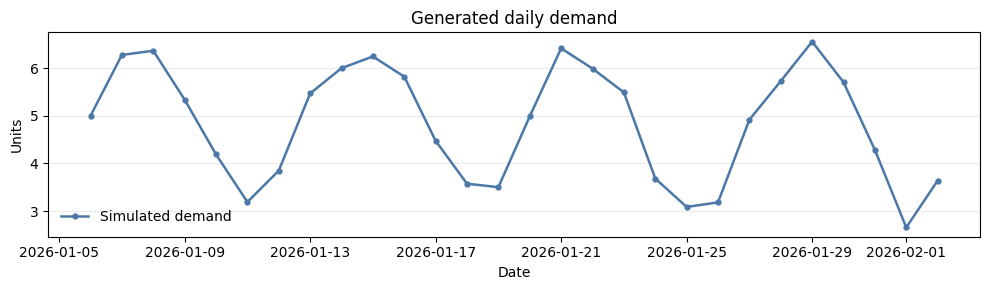

In [3]:
# Plot the complete generated path before inventory decisions change the state.
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(demand["date"], demand["y"], color="#4C78A8", marker="o",
        markersize=3.5, linewidth=1.8, label="Simulated demand")
ax.set(title="Generated daily demand", xlabel="Date", ylabel="Units")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 2. Start inventory and process the first review cycle

`InventoryStateDataFrame` holds the current state for each SKU. We explicitly supply 40 opening units rather than deriving stock from the generated demand. `initialize_from_observed` sets backlog and pipeline to zero.

This example reviews stock every four days, and deliveries take two days. `process_demand` moves one day forward: it receives due stock, then serves that day's demand. `allow_backorders=False` means unmet demand is lost rather than carried into a later period.

We process the first four daily rows before asking the policy for an order. At period 4, `is_review_period` becomes true and the resulting inventory position—on-hand plus pipeline minus backlog—is ready for the first review.

In [6]:
# Opening stock is a declared scenario input, not an estimate from the demand path.
opening_stock = pd.DataFrame({"unique_id": [sku], "observed_on_hand": [40.0]})
opening_stock

,unique_id,observed_on_hand
0,tea_250g,40.0


In [7]:
# Orders take two days to arrive; stock is reviewed every four days.
lead_time = 2
review_period = 4

# The maximum lead time sets the length of the state pipeline array.
opening_state = InventoryStateDataFrame(
    [sku], max_lead_time=lead_time, allow_backorders=False
).initialize_from_observed(
    opening_stock, on_hand_column="observed_on_hand", start_date=opening_date
)
opening_state

InventoryStateDataFrame(n_skus=1, total_on_hand=40, total_safety_stock=0, total_backorders=0, has_stockout=False, has_backorder=False)

In [8]:
# Select the first complete review cycle: one SKU-period row for each day.
first_cycle = demand.loc[demand["period"] < review_period, ["unique_id", "date", "y", "period"]]

print("Opening state")
print(opening_state.get_dataframe()[["unique_id", "on_hand", "backorders", "in_transit", "period", "date"]].to_string(index=False))
print("\nDemand before the first review")
print(first_cycle.to_string(index=False))

Opening state
unique_id  on_hand  backorders in_transit  period       date
 tea_250g     40.0         0.0 [0.0, 0.0]     0.0 2026-01-05

Demand before the first review
unique_id       date        y  period
 tea_250g 2026-01-06 5.000431       0
 tea_250g 2026-01-07 6.277308       1
 tea_250g 2026-01-08 6.366444       2
 tea_250g 2026-01-09 5.339118       3


In [9]:
state_after_demand = opening_state
for period in range(review_period):
    # Each call returns a new state after receiving due stock and serving one day.
    daily_demand = first_cycle.loc[first_cycle["period"] == period, ["unique_id", "date", "y"]]
    state_after_demand = state_after_demand.process_demand(
        daily_demand, review_period=review_period, period_frequency=period_frequency
    )

print("State at the first review")
print(
    state_after_demand.inventory_position()[
        ["unique_id", "on_hand", "backorders", "total_in_transit", "inventory_position", "period", "date"]
    ].to_string(index=False)
)

State at the first review
unique_id   on_hand  backorders  total_in_transit  inventory_position  period       date
 tea_250g 17.016699         0.0               0.0           17.016699     4.0 2026-01-09


## 3. Give the policy its target

`OrderUpToPolicy` needs a target for its protection horizon: lead time plus review period. We choose a two-day lead time and a four-day review period, so the target covers six days.

This notebook does not fit a forecast. Instead, it supplies a 42-unit cumulative target calculated outside Stockcast. Its end date is six days after the forecast origin, and its probability matches the policy service level of 0.95. Keeping those fields together lets Stockcast validate what the target represents.

In [10]:
# One direct cumulative target per SKU for the six-day protection horizon.
target_for_lead_time_1 = pd.DataFrame({
    "unique_id": [sku],
    "protection_target": [42.0],
    "target_end_date": [pd.Timestamp("2026-01-15")],
})
target_for_lead_time_1

,unique_id,protection_target,target_end_date
0,tea_250g,42.0,2026-01-15


In [11]:

# The policy requests enough stock to raise inventory position to the target.
policy = OrderUpToPolicy(
    lead_time=lead_time,
    review_period=review_period,
    service_level=0.95,
    allow_backorders=False,
).fit(
    target_for_lead_time_1,
    target_column="protection_target",
    target_probability=0.95,
    protection_horizon=lead_time + review_period,
    target_source="external_direct",
    forecast_origin=state_after_demand.get_dataframe()["date"].iloc[0],
    forecast_frequency="D",
    target_end_date_column="target_end_date",
)

print("Fitted target")
print(policy.get_target_levels().to_string(index=False))
print("\nTarget metadata")
print(pd.DataFrame([policy.get_target_metadata()]).to_string(index=False))

Fitted target
unique_id  target_level
 tea_250g          42.0

Target metadata
                 representation  target_probability  protection_horizon   target_source     forecast_origin forecast_frequency     target_end_date
direct_protection_period_target                0.95                   6 external_direct 2026-01-09T00:00:00                  D 2026-01-15T00:00:00


## 4. Ask for an order

At the review period, `predict` reads the current inventory position and returns an `OrderDecision` for the amount needed to reach 42. We pass the current state period so the decision records both its order period and the expected delivery period.

The decision is only a request. Calling `predict` does not change stock or the pipeline.

In [12]:
# The fourth demand update is an eligible review period for review_period=4.
assert bool(state_after_demand.get_dataframe()["is_review_period"].iloc[0])
# current_period anchors the order and expected-delivery timing in the decision.
decision = policy.predict(
    state_after_demand,
    current_period=int(state_after_demand.get_dataframe()["period"].iloc[0]),
)
print(decision.get_dataframe().to_string(index=False))

unique_id  order_quantity  target_level  inventory_position  reorder_point  order_period  expected_delivery_period
 tea_250g       24.983301          42.0           17.016699            NaN             4                         6


## 5. Put the order in the pipeline

`update_inventory_with_orders` validates the decision timing and adds the accepted quantity to the pipeline slot for the configured lead time. The order therefore raises inventory position immediately, but it does not increase on-hand stock until the next daily update receives it.

The assertions below make those timing rules executable: expected delivery is order period plus lead time, on-hand is unchanged at placement, and the pipeline contains exactly the requested quantity.

In [13]:
# Apply the request: this changes pipeline state, not current physical stock.
state_after_order = update_inventory_with_orders(
    state_after_demand, decision, policy=policy
)
state_after_order

InventoryStateDataFrame(n_skus=1, total_on_hand=17, total_safety_stock=0, total_backorders=0, has_stockout=False, has_backorder=False)

In [14]:

after_order_view = state_after_order.inventory_position()[
    ["unique_id", "on_hand", "latest_order", "in_transit", "total_in_transit", "inventory_position", "period", "date"]
]
print(after_order_view.to_string(index=False))

assert decision.get_dataframe().loc[0, "expected_delivery_period"] == decision.get_dataframe().loc[0, "order_period"] + lead_time
assert state_after_order.get_dataframe().loc[0, "on_hand"] == state_after_demand.get_dataframe().loc[0, "on_hand"]
assert state_after_order.get_dataframe().loc[0, "in_transit"].sum() == decision.get_dataframe().loc[0, "order_quantity"]

unique_id   on_hand  latest_order                in_transit  total_in_transit  inventory_position  period       date
 tea_250g 17.016699     24.983301 [0.0, 24.983300799512378]         24.983301                42.0     4.0 2026-01-09


## 6. Follow the daily updates

Now apply the same primitives to every row in the generated demand path. Each iteration processes demand; only rows where `is_review_period` is true ask the policy for an order and place it in the pipeline. `history_rows` is a small caller-owned record so we can plot what changed after each day.

The final figure combines the demand path with Stockcast's `plot_inventory` helper. The lower blue step line is **end-of-day on-hand stock**: receipts arrive first, and then the same day's demand is served. Orange markers show order dates and quantities. Green triangles identify receipt days, but their vertical position is the resulting end-of-day stock—not the quantity received. The pale orange region spans the two-day lead time from an order to its receipt.

The first receipt makes the sequence concrete. The previous day closes with 12.83 units; 24.98 units arrive; then demand of 3.19 is served. The green marker therefore sits at `12.83 + 24.98 - 3.19 = 34.62` units. The package flow is correct—the earlier chart simply did not explain what that marker encoded.

This introduction keeps the visual focused on on-hand stock. Notebook 02 uses `SimulationEngine` to produce the canonical event ledger and the full set of package visualizations.

In [18]:
# Start a fresh state so the timeline includes every generated demand period.
timeline_state = InventoryStateDataFrame(
    [sku], max_lead_time=lead_time, allow_backorders=False
).initialize_from_observed(
    opening_stock, on_hand_column="observed_on_hand", start_date=opening_date
)
timeline_state

InventoryStateDataFrame(n_skus=1, total_on_hand=40, total_safety_stock=0, total_backorders=0, has_stockout=False, has_backorder=False)

In [19]:
# Keep a simple reader-facing history; it is not the engine event ledger.
# Include the opening state so the step chart has a real starting point.
history_rows = [{
    "date": opening_date,
    "demand": float("nan"),
    "received": 0.0,
    "ordered": 0.0,
    "on_hand": 40.0,
    "pipeline": 0.0,
    "inventory_position": 40.0,
}]
for period in demand["period"]:
    # process_demand expects the complete demand frame for one date.
    daily_demand = demand.loc[
        demand["period"] == period, ["unique_id", "date", "y"]
    ]
    # Advance state: receive due pipeline stock, then fulfill this demand.
    timeline_state = timeline_state.process_demand(
        daily_demand, review_period=review_period, period_frequency=period_frequency
    )
    # The caller controls review timing in this component-level walk-through.
    if bool(timeline_state.get_dataframe()["is_review_period"].iloc[0]):
        # Calculate a request from the updated inventory position.
        daily_decision = policy.predict(
            timeline_state, current_period=int(timeline_state.get_dataframe()["period"].iloc[0])
        )
        # Schedule that request into the positive-lead-time pipeline.
        timeline_state = update_inventory_with_orders(
            timeline_state, daily_decision, policy=policy
        )
    # Capture the state after ordering for the tutorial time series.
    state_row = timeline_state.inventory_position().iloc[0]
    history_rows.append({
        "date": state_row["date"],
        "demand": daily_demand["y"].iloc[0],
        "received": state_row["latest_received"],
        "ordered": state_row["latest_order"],
        "on_hand": state_row["on_hand"],
        "pipeline": state_row["total_in_transit"],
        "inventory_position": state_row["inventory_position"],
    })

history = pd.DataFrame(history_rows)
history.head().round(2)

,date,demand,received,ordered,on_hand,pipeline,inventory_position
0,2026-01-05,NaN,0.0,0.00,40.00,0.00,40.00
1,2026-01-06,5.00,0.0,0.00,35.00,0.00,35.00
2,2026-01-07,6.28,0.0,0.00,28.72,0.00,28.72
3,2026-01-08,6.37,0.0,0.00,22.36,0.00,22.36
4,2026-01-09,5.34,0.0,24.98,17.02,24.98,42.00


      date  demand  received  ordered  on_hand  pipeline  inventory_position
2026-01-05     NaN      0.00     0.00    40.00      0.00               40.00
2026-01-06    5.00      0.00     0.00    35.00      0.00               35.00
2026-01-07    6.28      0.00     0.00    28.72      0.00               28.72
2026-01-08    6.37      0.00     0.00    22.36      0.00               22.36
2026-01-09    5.34      0.00    24.98    17.02     24.98               42.00
2026-01-10    4.19      0.00     0.00    12.83     24.98               37.81
2026-01-11    3.19     24.98     0.00    34.62      0.00               34.62


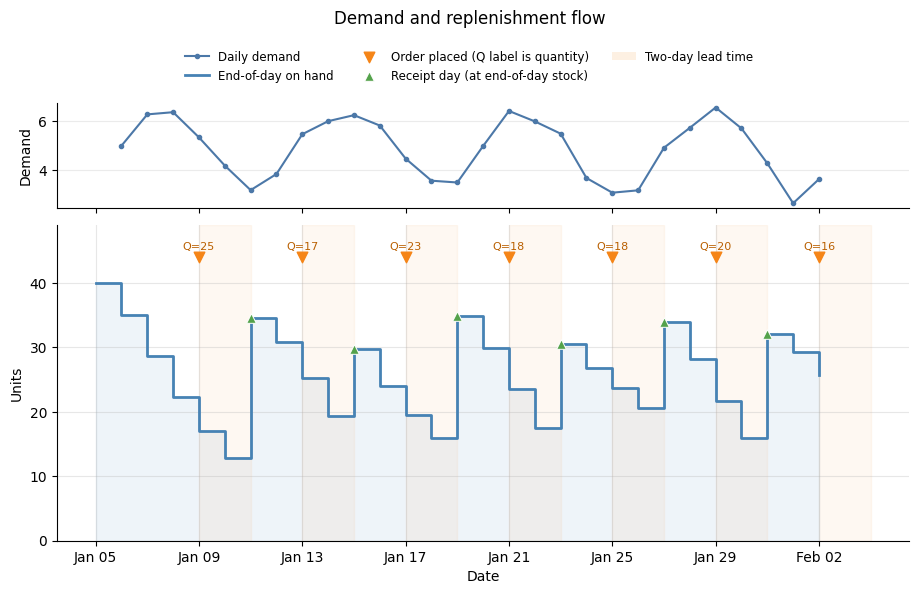

In [ ]:

# plot_inventory accepts a result-like history with the same fields as the manual loop.
plot_history = history.assign(
    unique_id=sku,
    period=range(len(history)),
    latest_shortage=0.0,
)
tutorial_result = SimpleNamespace(
    history=plot_history,
    policy_name="Order-up-to tutorial",
)

# A small demand panel preserves context without competing with inventory state.
fig, (demand_ax, inventory_ax) = plt.subplots(
    2, 1, figsize=(11, 6), sharex=True,
    gridspec_kw={"height_ratios": [1, 3], "hspace": 0.08},
)
demand_line, = demand_ax.plot(
    plot_history["period"], plot_history["demand"],
    color="#4C78A8", marker="o", markersize=3, linewidth=1.5,
    label="Daily demand",
)
demand_ax.set_ylabel("Demand")
demand_ax.grid(axis="y", alpha=0.25)
demand_ax.spines[["top", "right"]].set_visible(False)

# Draw the package inventory visual on the lower axis.
plot_inventory(tutorial_result, sku=sku, ax=inventory_ax)
on_hand_line = inventory_ax.lines[0]
on_hand_line.set(
    drawstyle="steps-post", linewidth=2.0, zorder=3,
    label="End-of-day on hand",
)
# Replace the helper's continuous fill with a discrete one matching the step line.
inventory_ax.collections[0].remove()
inventory_ax.fill_between(
    plot_history["period"], 0, plot_history["on_hand"],
    step="post", color="#2C7FB8", alpha=0.08, zorder=0,
)

order_events = plot_history.loc[plot_history["ordered"] > 0]
receipt_events = plot_history.loc[plot_history["received"] > 0]
order_marker_y = plot_history["on_hand"].max() + 4
# Shade each order-to-delivery interval; the last one remains open beyond the horizon.
for event in order_events.itertuples(index=False):
    inventory_ax.axvspan(
        event.period, event.period + lead_time,
        color="#F58518", alpha=0.055, zorder=0,
    )
order_points = inventory_ax.scatter(
    order_events["period"], [order_marker_y] * len(order_events),
    marker="v", s=58, color="#F58518", zorder=4,
    label="Order placed (Q label is quantity)",
)
for event in order_events.itertuples(index=False):
    inventory_ax.text(
        event.period, order_marker_y + 0.8, f"Q={event.ordered:.0f}",
        ha="center", va="bottom", color="#B95F00", fontsize=8,
    )

# Receipt markers sit on closing stock because process_demand receives, then serves demand.
receipt_points = inventory_ax.scatter(
    receipt_events["period"], receipt_events["on_hand"],
    marker="^", s=48, color="#54A24B", edgecolor="white",
    linewidth=0.7, zorder=5, label="Receipt day (at end-of-day stock)",
)

# Replace the helper legend with one shared, explicit key for both panels.
inventory_ax.get_legend().remove()
lead_time_key = Patch(facecolor="#F58518", alpha=0.12, label="Two-day lead time")
fig.legend(
    handles=[demand_line, on_hand_line, order_points, receipt_points, lead_time_key],
    loc="upper center", bbox_to_anchor=(0.5, 0.945), ncol=3, frameon=False,
    fontsize=8.5,
)
fig.suptitle("Demand and replenishment flow", y=0.995)
inventory_ax.set(title="", xlabel="Date", ylabel="Units")
tick_rows = plot_history.iloc[::4]
inventory_ax.set_xticks(tick_rows["period"])
inventory_ax.set_xticklabels(tick_rows["date"].dt.strftime("%b %d"))
inventory_ax.set_ylim(0, order_marker_y + 5)
inventory_ax.spines[["top", "right"]].set_visible(False)
fig.subplots_adjust(top=0.84)
plt.show()

# Verify the first receipt-day balance shown in the explanation above.
first_receipt_index = history.index[history["received"] > 0][0]
first_receipt_close = (
    history.loc[first_receipt_index - 1, "on_hand"]
    + history.loc[first_receipt_index, "received"]
    - history.loc[first_receipt_index, "demand"]
)
assert abs(history.loc[first_receipt_index, "on_hand"] - first_receipt_close) < 1e-9
assert (history["pipeline"] >= 0).all()
assert (history["on_hand"] >= 0).all()
assert (history["inventory_position"] >= history["on_hand"]).all()